In [107]:
import project
import anuga
import pandas as pd
from tqdm.notebook import tqdm

import numpy as np
import os
import matplotlib.pyplot as plt

%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')


In [108]:
ls -lh

total 16M
-rw-r--r-- 1 steve steve  18K Dec  3 10:03 anuga_20251202_203318.log
-rw-r--r-- 1 steve steve 337K Dec  3 10:17 nb_compare_gauge_data.ipynb
-rw-r--r-- 1 steve steve 1.1M Dec  2 19:58 nb_extract_gauge_data.ipynb
drwxr-xr-x 2 steve steve 4.0K Dec  2 20:41 _plot/
-rwxr-xr-x 1 steve steve 1.5K Dec  2 20:29 project.py*
drwxr-xr-x 2 steve steve 4.0K Dec  2 20:29 __pycache__/
-rw-r--r-- 1 steve steve 3.2K Dec  2 20:29 run_merimbula.log
-rwxr-xr-x 1 steve steve 6.8K Dec  2 19:58 run_merimbula.py*
-rw-r--r-- 1 steve steve 2.2M Dec  2 20:29 template_sept_2003_10785_weeds_20251202_202941.sww
-rw-r--r-- 1 steve steve 3.5M Dec  2 20:27 template_sept_2003_17156_weeds_20251202_202722.sww
-rw-r--r-- 1 steve steve 8.8M Dec  2 20:28 template_sept_2003_43200_weeds_20251202_202802.sww
-rw-r--r-- 1 steve steve 7.7K Dec  2 19:58 weed_zones.py


In [112]:
def open_sww_file(swwfile, verbose=False):
    splotter = anuga.SWW_plotter(swwfile)

    splotter.filename = swwfile

    starttime = splotter.starttime
    dt = pd.to_datetime(starttime, unit='s')
    if verbose:
        print(f'Start time: {dt}')

    # Convert to absolute corrdinates
    xc = splotter.xc + splotter.xllcorner
    yc = splotter.yc + splotter.yllcorner


    gauge_ids = []
    for row in zip(gauge_x, gauge_y):
        tid = np.argmin( (xc-row[0])**2 + (yc-row[1])**2 )
        if verbose:
            print(f'Gauge at ({row[0]:.1f}, {row[1]:.1f}) assigned to triangle {tid}')
        gauge_ids.append(tid)

    return splotter, gauge_ids

def get_flow_through_cross_section(splotter, polyline, verbose=False):

    # assume open_sww_file has been called
    try:
        mesh = splotter.mesh
    except AttributeError:
        from anuga.file.sww import get_mesh_and_quantities_from_file
        mesh, _, __ = get_mesh_and_quantities_from_file(splotter.filename, verbose=verbose)
        
    segments = mesh.get_intersecting_segments(polyline, verbose=verbose)

    Q = []
    for k, t in enumerate(splotter.time):
        total_flow = 0
        for seg in segments:
            i = seg.triangle_id
            depth = splotter.depth[k,i]
            uh = splotter.xmom[k,i]
            vh = splotter.ymom[k,i]
            normal = seg.normal

            # Inner product of momentum vector with segment normal [m^2/s]
            normal_momentum = uh*normal[0] + vh*normal[1]

            # Flow across this segment [m^3/s]
            segment_flow = normal_momentum * seg.length

            # Accumulate
            total_flow += segment_flow

        # Store flow at this timestep
        Q.append(total_flow)

    return splotter.time, Q

In [114]:
verbose = False

# Set up the sww files to compare
swwfiles = ['template_sept_2003_10785_weeds_20251202_202941.sww',
            'template_sept_2003_17156_weeds_20251202_202722.sww',
            'template_sept_2003_43200_weeds_20251202_202802.sww']

num_of_triangles = []
for swwfile in swwfiles:
    num_of_triangles.append(int(swwfile.split('_')[3]))

gauge_location = pd.read_csv(project.gauge_filename)
gauge_x = gauge_location['easting'].to_numpy()
gauge_y = gauge_location['northing'].to_numpy()



splotters = []
gauge_id_list = []

for n, swwfile in enumerate(swwfiles):
    splotter, gauge_ids = open_sww_file(swwfile, verbose=verbose)
    splotters.append(splotter)
    gauge_id_list.append(gauge_ids) 


# polyline at bridge
polyline = [[759205.0-10, 5912912+10],
            [759205.0+45, 5912912-30]]




Figure files for each frame will be stored in _plot
Figure files for each frame will be stored in _plot
Figure files for each frame will be stored in _plot


Gauge gauge4 at (759205.0, 5912912.0)


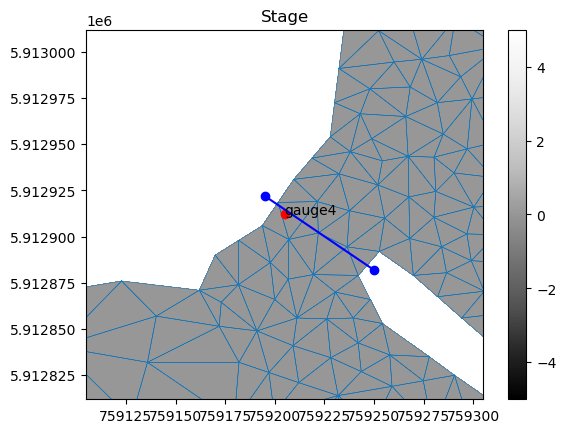

In [115]:
splotter = splotters[1]

plt.tripcolor(splotter.triang,
              facecolors = splotter.stage[0,:],
              cmap='Greys_r',
              vmin= -5,
              vmax= 5.0
              )
plt.triplot(splotter.triang, linewidth = 0.4)
plt.colorbar();
plt.title("Stage");
plt.scatter(gauge_x, gauge_y, color='red')
#for i in range(8):
for i in range(3,4):
    plt.annotate(gauge_location['name'][i], [gauge_x[i], gauge_y[i]])
    print(f'Gauge {gauge_location["name"][i]} at ({gauge_x[i]}, {gauge_y[i]})')

plt.xlim(759205-100, 759205.0+100)
plt.ylim(5912912-100, 5912912+100)



#plt.scatter([759205.0-10, 759205.0+45], [5912912+10, 5912912-30], color='blue')
plt.scatter([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')
plt.plot([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')
plt.show()


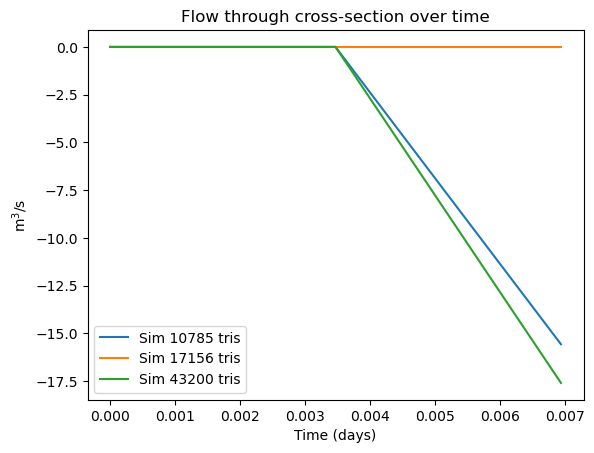

In [116]:

for n, splotter in enumerate(splotters):
    t, Q = get_flow_through_cross_section(splotter, polyline, verbose=verbose) 
    plt.plot(t/3600/24, Q, label=f'Sim {num_of_triangles[n]} tris')
plt.xlabel('Time (days)')
plt.ylabel('m$^3$/s')
plt.title('Flow through cross-section over time')
plt.legend()
plt.show()

Simulation 0 has 3 timesteps and 10785 triangles.
Simulation 1 has 3 timesteps and 17156 triangles.
Simulation 2 has 3 timesteps and 43200 triangles.


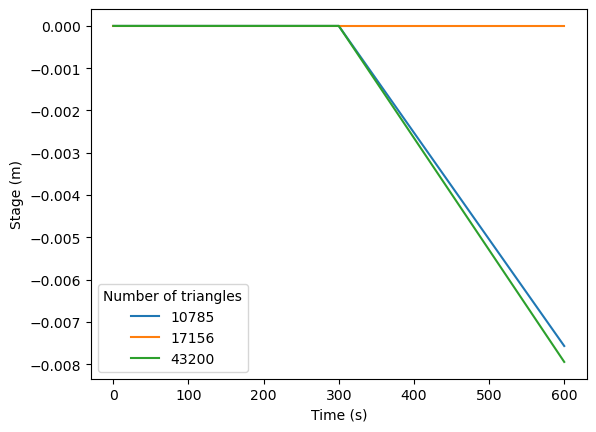

In [117]:
gid = 4  # gauge id to plot
for n,splotter in enumerate(splotters):
    print(f'Simulation {n} has {splotter.stage.shape[0]} timesteps and {splotter.stage.shape[1]} triangles.')
    plt.plot(splotter.time, splotter.stage[:,gauge_id_list[n][gid]], label=num_of_triangles[n])

plt.legend(title='Number of triangles')
plt.xlabel('Time (s)')
plt.ylabel('Stage (m)')
plt.show()

Gauge 4 measured stage data is missing gauge4


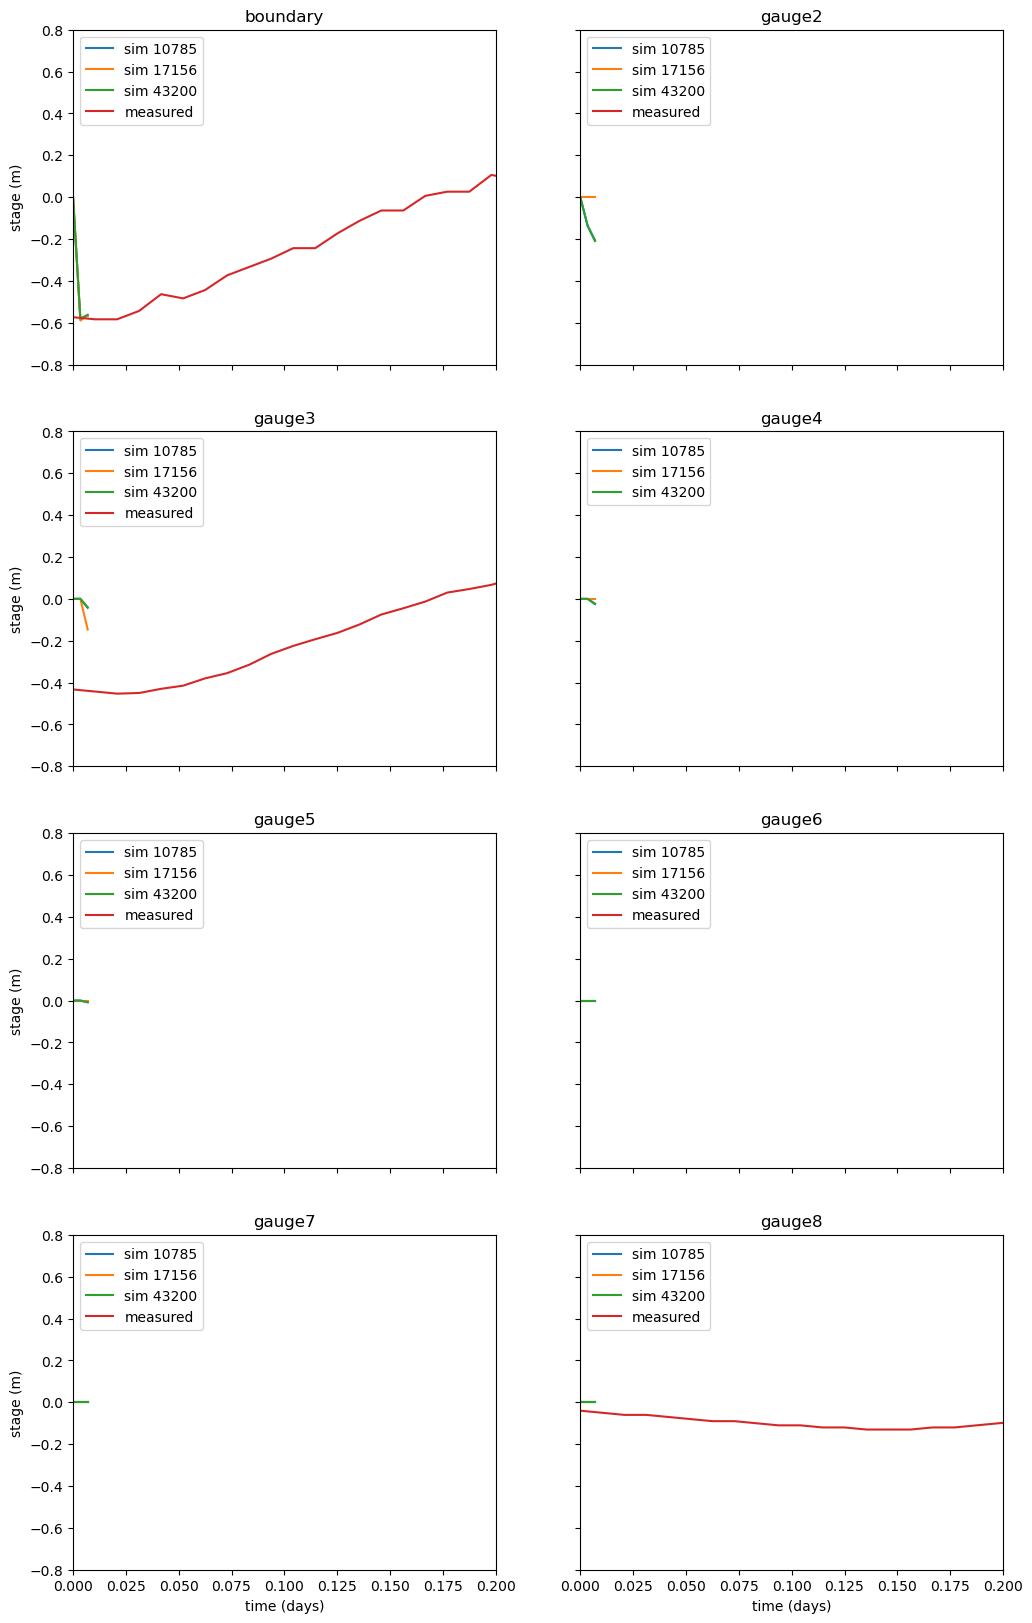

In [118]:
model_dir = '../../model_data_sept_2003'

sites = []

#for row in gauge_location.iterrows():

for index, row in gauge_location.iterrows():
    filename = anuga.join(model_dir,row['name']+'.txt')

    if row['name'] == 'gauge4':
        print(f"Gauge 4 measured stage data is missing {row['name']}")
        site = None
    else:
        site = pd.read_fwf(filename, header=None)
        site.columns = ['time', 'measured']
        site['time'] = site['time'] - 265

    sites.append(site)
        

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(12,20), sharex=True, sharey=True)


for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]):

    ax.set_title(gauge_location['name'][i])
    for n, (splotter, gauge_ids) in enumerate(zip(splotters, gauge_id_list)): 
        #pass
        ax.plot(splotter.time/3600/24, splotter.stage[:,gauge_ids[i]], label='sim '+str(num_of_triangles[n]))
    

    if gauge_location['name'][i] == 'gauge4':
        pass
    else:
        sites[i].plot('time','measured', ax=ax, label='measured')

    ax.legend(loc='upper left')
    ax.set_xlim(0.0, 0.2)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel('time (days)')
    ax.set_ylabel('stage (m)')

plt.show()    
